In [1]:
# Imports 

import os
import pandas as pd
import numpy as np
from scipy.stats import shapiro, norm
from matplotlib import pyplot as plt
import time

In [2]:
# Directories and Global Variables
DATA_DIRECTORY = "./results"

# Retreive all Directories and files in the results 
QUALITY_DIRECTORIES = os.listdir(DATA_DIRECTORY)

In [3]:
files = []
for q in QUALITY_DIRECTORIES: 
    runs = os.listdir(f"{DATA_DIRECTORY}/{q}")
    for f in runs: 
        files.append(f"{q}/{f}")
files

['all-off/run_06.csv',
 'all-off/run_14.csv',
 'all-off/run_29.csv',
 'all-off/run_03.csv',
 'all-off/run_02.csv',
 'all-off/run_70.csv',
 'all-off/run_102.csv',
 'all-off/run_114.csv',
 'all-off/run_72.csv',
 'all-off/run_99.csv',
 'all-off/run_98.csv',
 'all-off/run_101.csv',
 'all-off/run_115.csv',
 'all-off/run_105.csv',
 'all-off/run_88.csv',
 'all-off/run_62.csv',
 'all-off/run_112.csv',
 'all-off/run_107.csv',
 'all-off/run_50.csv',
 'all-off/run_92.csv',
 'all-off/run_79.csv',
 'all-off/run_84.csv',
 'all-off/run_90.csv',
 'all-off/run_46.csv',
 'all-off/run_120.csv',
 'all-off/run_81.csv',
 'all-off/run_94.csv',
 'all-off/run_83.csv',
 'all-off/run_24.csv',
 'all-off/run_09.csv',
 'ambient-mode/run_13.csv',
 'ambient-mode/run_11.csv',
 'ambient-mode/run_38.csv',
 'ambient-mode/run_15.csv',
 'ambient-mode/run_16.csv',
 'ambient-mode/run_117.csv',
 'ambient-mode/run_71.csv',
 'ambient-mode/run_65.csv',
 'ambient-mode/run_58.csv',
 'ambient-mode/run_64.csv',
 'ambient-mode/run_73

In [4]:
example = pd.read_csv(f"{DATA_DIRECTORY}/{files[0]}")[['Time', 'SYSTEM_POWER (Watts)']]
first_time = example['Time'].iloc[0]
example['Time'] = example['Time'].apply(lambda x: (x - first_time) / 1000)
example.head(10)

,Time,SYSTEM_POWER (Watts)
0,0.000,8.640646
1,0.000,8.640646
2,0.206,2.221175
3,0.408,2.221175
4,0.610,2.221175
5,0.820,2.221175
6,1.023,2.595312
7,1.233,2.595312
8,1.442,2.595312
9,1.650,2.595312


In [5]:
# Check whether Data is normal

stats, p_val = shapiro(example['SYSTEM_POWER (Watts)'])

print(f"With p-val {p_val}, the data is {'NOT NORMAL' if p_val < 0.05 else 'NORMAL'}")

With p-val 1.1864235031538216e-29, the data is NOT NORMAL


In [6]:
# Normalising the data

mean = example['SYSTEM_POWER (Watts)'].mean()
std = example['SYSTEM_POWER (Watts)'].std()
outlier = []
max_diff = 0
print(f"std: {3 * std}")
for idx, val in enumerate(example['SYSTEM_POWER (Watts)']): 
    diff = mean - val
    if np.abs(diff) > max_diff: max_diff = np.abs(diff) 
    if np.abs(diff) > 3*std: 
        print(f"Found outlier at {idx}")
        outlier.append(idx)

print(max_diff)
normalised_example = example.drop(index=outlier) 
normalised_example   


std: 1.7711237292219826
Found outlier at 0
Found outlier at 1
6.254865449993577


,Time,SYSTEM_POWER (Watts)
2,0.206,2.221175
3,0.408,2.221175
4,0.610,2.221175
5,0.820,2.221175
6,1.023,2.595312
...,...,...
287,59.274,2.414130
288,59.483,2.414130
289,59.693,2.414130
290,59.902,2.414130


In [ ]:
#Plotting data distribution
plt.plot(example['Time'], example['SYSTEM_POWER (Watts)'])
plt.xlabel("Delta")
plt.ylabel("System Power measurement (Watts)")

{'bodies': [<matplotlib.collections.FillBetweenPolyCollection at 0x130b3e7b0>],
 'cmaxes': <matplotlib.collections.LineCollection at 0x117e69580>,
 'cmins': <matplotlib.collections.LineCollection at 0x117e1a1e0>,
 'cbars': <matplotlib.collections.LineCollection at 0x117b8a9f0>}

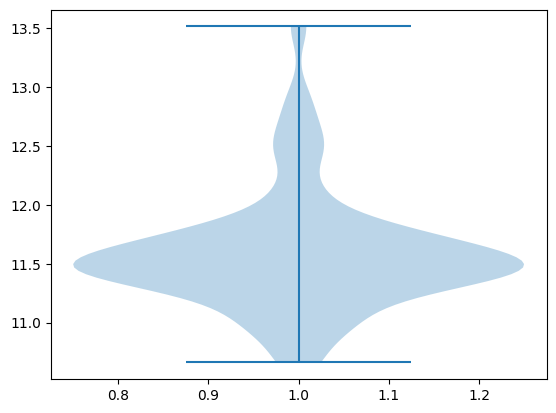

In [20]:
# Violin plots

plt.violinplot(example['SYSTEM_POWER (Watts)'])


### Creating a general setup to create combinations by subcategories 

The outlier removal didn't work, possibly becasue there are not enough sample. Might have to do something else. 

In [21]:
dataframes = {}
for f in files: 
    print(f"======== Converting file '{f}' ========")
    df = pd.read_csv(f"{DATA_DIRECTORY}/{f}")[['Time', 'SYSTEM_POWER (Watts)']]
    first_time = df['Time'].iloc[0]
    df['Time'] = df['Time'].apply(lambda x: (x - first_time) / 1000)
    dataframes[f] = df
    
dataframes[f]

======== Converting file 'all-off/run_11.csv' ========
======== Converting file 'all-off/run_04.csv' ========
======== Converting file 'all-off/run_03.csv' ========
======== Converting file 'all-off/run_02.csv' ========
======== Converting file 'all-off/run_19.csv' ========
======== Converting file 'ambient-mode/run_12.csv' ========
======== Converting file 'ambient-mode/run_05.csv' ========
======== Converting file 'ambient-mode/run_01.csv' ========
======== Converting file 'ambient-mode/run_16.csv' ========
======== Converting file 'ambient-mode/run_08.csv' ========
======== Converting file 'stable-volume/run_10.csv' ========
======== Converting file 'stable-volume/run_14.csv' ========
======== Converting file 'stable-volume/run_17.csv' ========
======== Converting file 'stable-volume/run_18.csv' ========
======== Converting file 'stable-volume/run_20.csv' ========
======== Converting file 'voice-boost/run_06.csv' ========
======== Converting file 'voice-boost/run_07.csv' ========
==

,Time,SYSTEM_POWER (Watts)
0,0.000,20.379541
1,0.000,20.379541
2,0.213,20.379541
3,0.423,20.379541
4,0.633,20.379541
...,...,...
285,59.354,19.100046
286,59.561,19.100046
287,59.771,18.933527
288,59.972,18.933527


In [22]:
for f, df in dataframes.items():
    stats, p_val = shapiro(df['SYSTEM_POWER (Watts)'])

    print(f"With p-val {p_val}, the data in {f} is {'NOT NORMAL' if p_val < 0.05 else 'NORMAL'}\n==============================================================")

With p-val 1.4390344185798182e-14, the data in all-off/run_11.csv is NOT NORMAL
With p-val 3.0064362146415607e-05, the data in all-off/run_04.csv is NOT NORMAL
With p-val 3.9129612407791556e-24, the data in all-off/run_03.csv is NOT NORMAL
With p-val 1.708819915951203e-20, the data in all-off/run_02.csv is NOT NORMAL
With p-val 2.3278985573734668e-15, the data in all-off/run_19.csv is NOT NORMAL
With p-val 4.462280589320513e-19, the data in ambient-mode/run_12.csv is NOT NORMAL
With p-val 1.8037473719058507e-19, the data in ambient-mode/run_05.csv is NOT NORMAL
With p-val 1.0930642056172998e-19, the data in ambient-mode/run_01.csv is NOT NORMAL
With p-val 5.671147224397799e-19, the data in ambient-mode/run_16.csv is NOT NORMAL
With p-val 9.013699403721381e-20, the data in ambient-mode/run_08.csv is NOT NORMAL
With p-val 1.0508605570307678e-15, the data in stable-volume/run_10.csv is NOT NORMAL
With p-val 1.745325419057727e-17, the data in stable-volume/run_14.csv is NOT NORMAL
With p-v

In [23]:
normalised_dataframes = {}
for f, df in dataframes.items(): 
    mean = df['SYSTEM_POWER (Watts)'].mean()
    std = df['SYSTEM_POWER (Watts)'].std()
    outlier = []
    max_diff = 0
    print(f"3x std: {3 * std} | mean: {mean}")
    for idx, val in enumerate(df['SYSTEM_POWER (Watts)']): 
        diff = mean - val
        abs = np.abs(diff)
        if abs > max_diff: max_diff = abs
        if abs > 3*std: 
            print(f"Found outlier at {idx}")
            outlier.append(idx)

    print(f"Maximum difference found: {max_diff}")
    n_df = df.drop(index=outlier) 
    normalised_dataframes[f] = n_df
    print("===============================================")

3x std: 1.5145018554336893 | mean: 11.588534660079853
Found outlier at 238
Found outlier at 239
Found outlier at 240
Found outlier at 241
Found outlier at 242
Maximum difference found: 1.9257933428498344
3x std: 2.0250571801051684 | mean: 20.736001507765582
Maximum difference found: 1.9969105558330504
3x std: 1.6824391767237366 | mean: 11.503521708034029
Found outlier at 161
Found outlier at 162
Found outlier at 163
Found outlier at 164
Found outlier at 165
Found outlier at 166
Found outlier at 167
Found outlier at 168
Found outlier at 169
Found outlier at 170
Found outlier at 171
Found outlier at 172
Found outlier at 173
Found outlier at 174
Found outlier at 175
Maximum difference found: 2.2070266928448774
3x std: 1.3920055126945545 | mean: 11.44393466463025
Found outlier at 0
Found outlier at 1
Maximum difference found: 3.672806515789672
3x std: 1.365861429726984 | mean: 11.600302212903289
Found outlier at 210
Found outlier at 211
Found outlier at 212
Found outlier at 213
Found outli

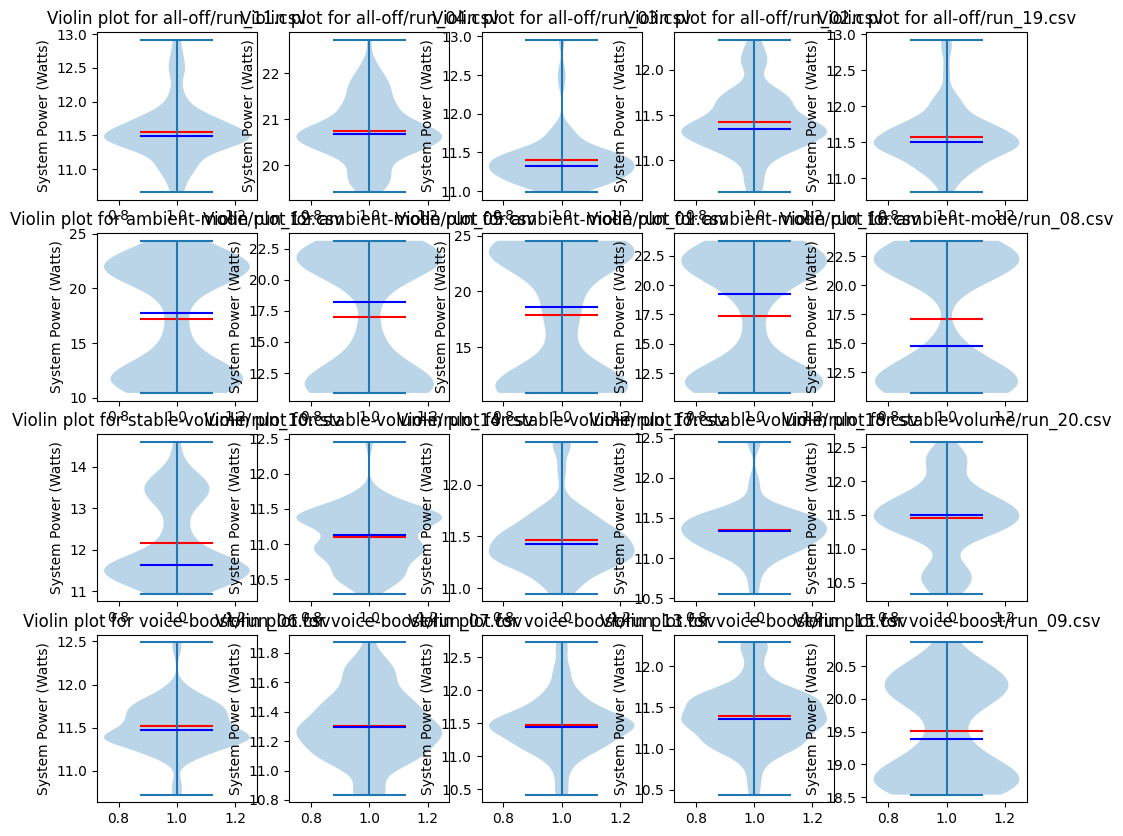

In [24]:
fig, plots = plt.subplots(nrows = len(QUALITY_DIRECTORIES), 
                               ncols = len(os.listdir(f"{DATA_DIRECTORY}/{QUALITY_DIRECTORIES[0]}")),
                               figsize =(12, 10))
plots = plots.flatten()

for idx, (f, df) in enumerate(normalised_dataframes.items()): 
    ax = plots[idx]
    ax.set_title(f"Violin plot for {f}")
    ax.set_ylabel('System Power (Watts)')
    parts = ax.violinplot(df['SYSTEM_POWER (Watts)'], showmeans=True, showmedians=True)
    parts['cmeans'].set_color('red')
    parts['cmedians'].set_color('blue')    

plt.show()

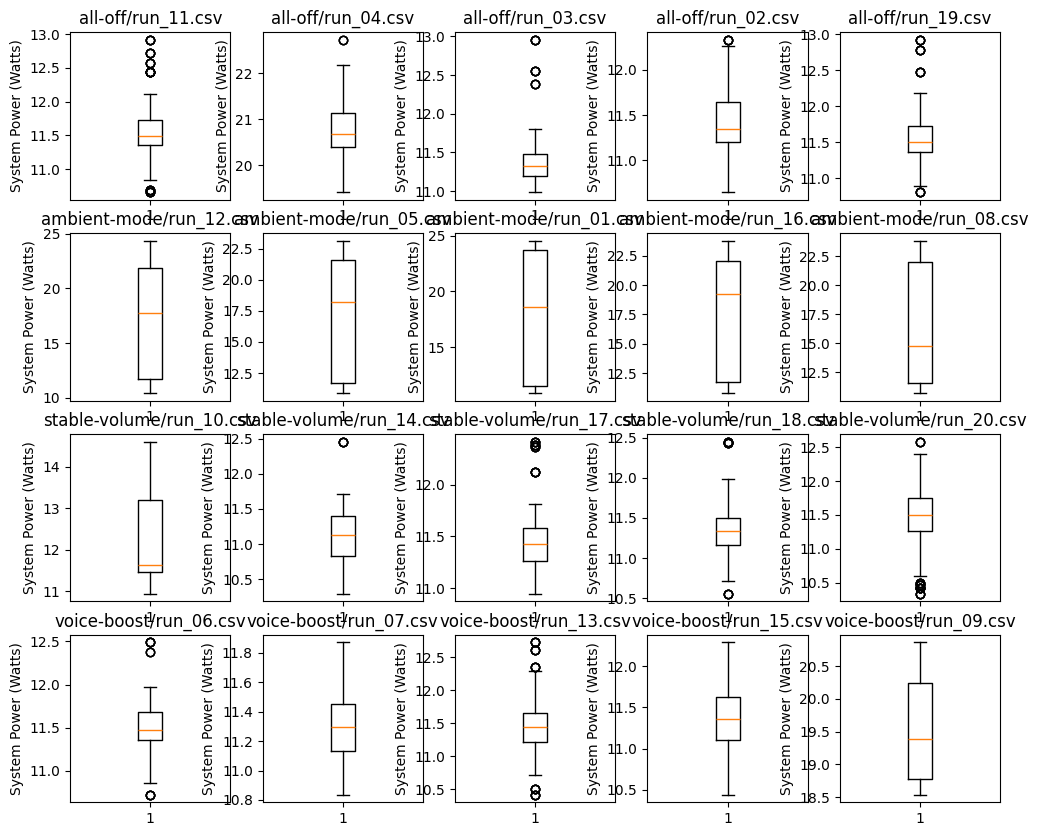

In [28]:
fig, plots = plt.subplots(nrows = len(QUALITY_DIRECTORIES), 
                               ncols = len(os.listdir(f"{DATA_DIRECTORY}/{QUALITY_DIRECTORIES[0]}")),
                               figsize =(12, 10))
plots = plots.flatten()

for idx, (f, df) in enumerate(normalised_dataframes.items()): 
    ax = plots[idx]
    ax.set_title(f"{f}")
    ax.set_ylabel('System Power (Watts)')
    ax.boxplot(df['SYSTEM_POWER (Watts)'])

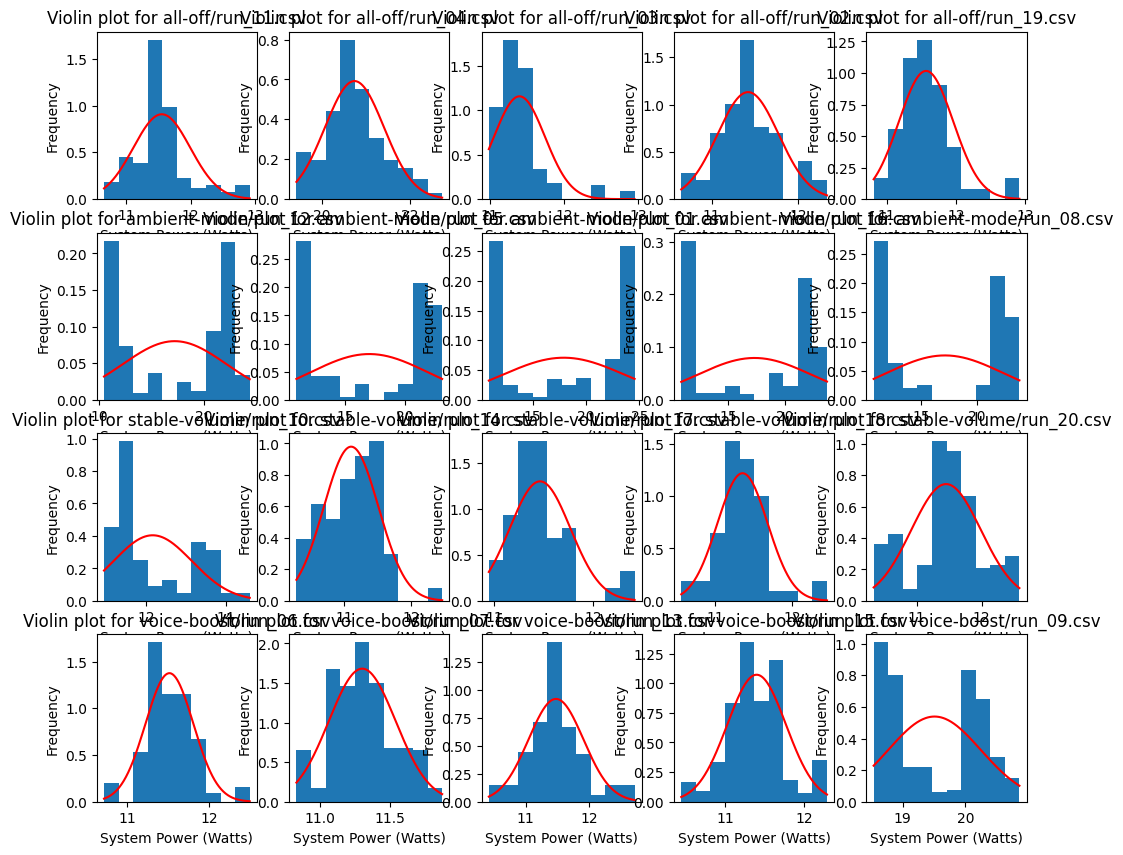

In [26]:
fig, plots = plt.subplots(nrows = len(QUALITY_DIRECTORIES), 
                               ncols = len(os.listdir(f"{DATA_DIRECTORY}/{QUALITY_DIRECTORIES[0]}")),
                               figsize =(12, 10))
plots = plots.flatten()

for idx, (f, df) in enumerate(normalised_dataframes.items()): 
    ax = plots[idx]
    ax.set_title(f"Violin plot for {f}")
    ax.set_xlabel('System Power (Watts)')
    ax.set_ylabel('Frequency')
    ax.hist(df['SYSTEM_POWER (Watts)'], density=True)
    mu, std = norm.fit(df['SYSTEM_POWER (Watts)'])
    x = np.linspace(df['SYSTEM_POWER (Watts)'].min(), df['SYSTEM_POWER (Watts)'].max(), 200)
    p = norm.pdf(x, mu, std)
    
    ax.plot(x, p, 'r')